This notebook compares Matching and Pauli Decompositions for a specific example.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append(f"./../")

from src.graphs import StaticGraph, IntersectingEdgesGraph, MultiEdgeGraph
from src.misc import graph_matchings_parallel
from qiskit.quantum_info import Operator


Original graph:


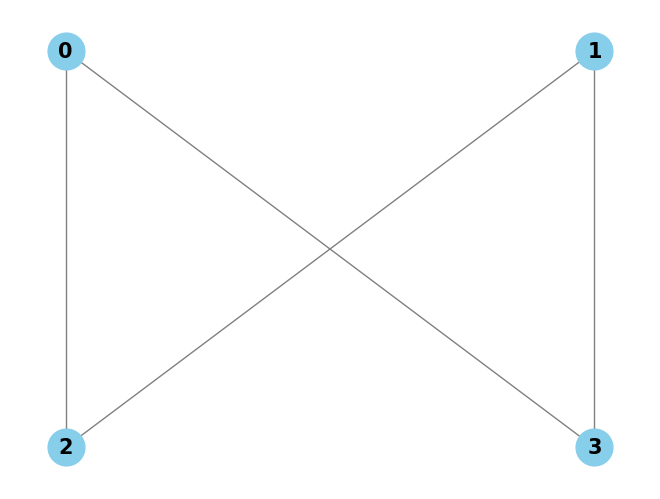

In [2]:
edges = {('00', '11'), ('01', '10'), ('00', '10'), ('01', '11')}

G = StaticGraph(edges)
print("Original graph:")
G.draw()

## Matching Decomposition

Relabeled graph:


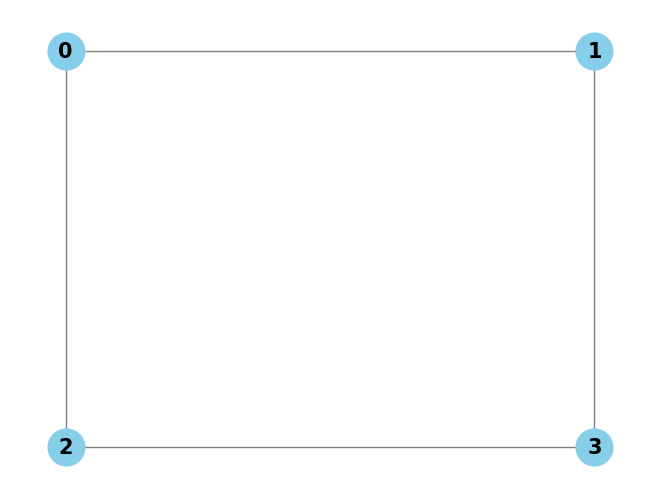

None

In [3]:
matchings = graph_matchings_parallel(edges)

relabeled_edges = set()
for m in matchings:
    relabeled_edges = relabeled_edges.union(m)

relabeled_G = StaticGraph(relabeled_edges)
print("Relabeled graph:")
display(relabeled_G.draw())

matching 1: {('11', '10'), ('00', '01')}


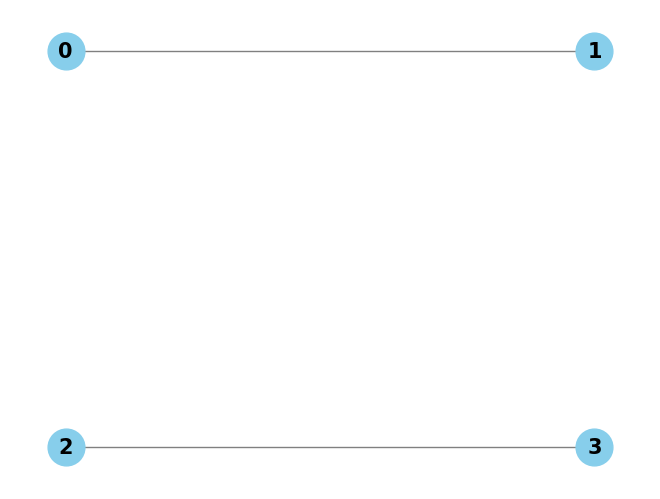

None

circuit 1:


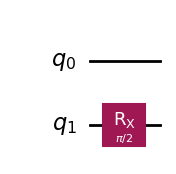

matching 2: {('11', '01'), ('00', '10')}


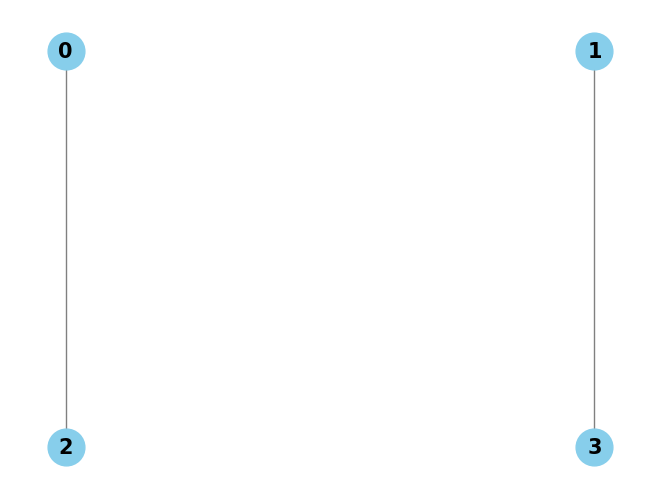

None

circuit 2:


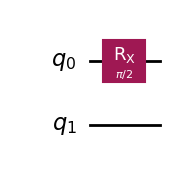

In [4]:
G = IntersectingEdgesGraph(edges, matchings='parallel')

for index, g in enumerate(G.subgraphs):
    print(f"matching {index+1}: {g.edges}")
    display(g.draw())
    qc = g.get_qc(simplified=True)
    print(f'circuit {index+1}:')
    display(qc.draw('mpl'))
    

Full circuit:


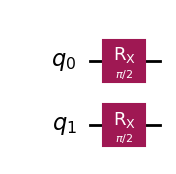

In [5]:
from qiskit import QuantumCircuit
import numpy as np

delta_t = 0.1

static_G = StaticGraph(edges)
intersecting_G = IntersectingEdgesGraph(edges, matchings='parallel')

n_steps = 1

full_qc = QuantumCircuit(static_G.n_qubits)
for _ in range(n_steps):
    for subgraph in intersecting_G.subgraphs:
        G = MultiEdgeGraph(subgraph.edges)
        G.rot_angle = delta_t / n_steps  # Example rotation angle
        sub_qc = G.get_qc(simplified=True)
        full_qc = full_qc.compose(sub_qc)

print("Full circuit:")
display(full_qc.draw('mpl'))

In [6]:
# Get the operator for the matching decomposition circuit
matching_operator = Operator(full_qc)
print(f"Matching circuit operator shape: {matching_operator.data.shape}")
# matching_operator = np.array(matching_operator.data)

Matching circuit operator shape: (4, 4)


## Pauli Decomposition

In [7]:
import itertools
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import Operator, Pauli, SparsePauliOp
import numpy as np

In [8]:
# static_G = StaticGraph(edges)
H = relabeled_G.get_adj_mat()
n = relabeled_G.n_qubits

# Decompose the Hamiltonian into Pauli basis
pauli_strings = []
coeffs = []

for pauli_string in ["".join(p) for p in itertools.product("IXYZ", repeat=n)]:
    P = Pauli(pauli_string)
    P_op = Operator(P).data
    coeff = np.trace(P_op.conj().T @ H) / (2**n)
    
    # For real symmetric matrices, coefficients should be real
    # Check that imaginary part is negligible
    if not np.isclose(np.imag(coeff), 0, atol=1e-10):
        print(f"Warning: Non-negligible imaginary coefficient {np.imag(coeff)} for Pauli string {pauli_string}")
    
    real_coeff = float(np.real(coeff))
    if not np.isclose(real_coeff, 0, atol=1e-10):
        pauli_strings.append(pauli_string)
        coeffs.append(real_coeff)

# Print the Pauli decomposition
print(f"Found {len(pauli_strings)} non-zero Pauli terms:")
for pauli_string, coeff in zip(pauli_strings, coeffs):
    print(f"{pauli_string}: {coeff:.2f}")


Found 2 non-zero Pauli terms:
IX: 1.00
XI: 1.00


Pauli Evolution Circuit:


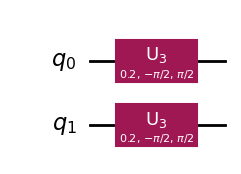

In [9]:
# Create quantum circuit 
pauli_qc = QuantumCircuit(n)

if coeffs:  # Only if we have non-zero coefficients
    pauli_op = SparsePauliOp(pauli_strings, coeffs)
    evo_gate = PauliEvolutionGate(pauli_op, time=delta_t)
    pauli_qc.append(evo_gate, range(n))

print("Pauli Evolution Circuit:")
decomposed_pauli_qc = pauli_qc.decompose().decompose().decompose()
display(decomposed_pauli_qc.draw('mpl'))

In [10]:
pauli_operator = Operator(decomposed_pauli_qc)
print(f"Pauli circuit operator shape: {pauli_operator.data.shape}")
# pauli_operator = np.array(pauli_operator.data)

Pauli circuit operator shape: (4, 4)


In [11]:
# Validate Pauli decomposition by reconstructing Hamiltonian
reconstructed_H = np.zeros_like(H, dtype=complex)

for pauli_string, coeff in zip(pauli_strings, coeffs):
    P = Pauli(pauli_string)
    P_matrix = Operator(P).data
    reconstructed_H += coeff * P_matrix

# Check if decomposition is correct
is_correct = np.allclose(H, reconstructed_H, atol=1e-10)
max_error = np.max(np.abs(H - reconstructed_H))

print("\nOriginal Adjacency Matrix:")
print(H)
print("\nReconstructed Adjacency Matrix:")
print(np.real(reconstructed_H))

print(f"\nPauli Decomposition correct: {is_correct}")
print(f"Max error: {max_error:.2e}")


Original Adjacency Matrix:
[[0 1 1 0]
 [1 0 0 1]
 [1 0 0 1]
 [0 1 1 0]]

Reconstructed Adjacency Matrix:
[[0. 1. 1. 0.]
 [1. 0. 0. 1.]
 [1. 0. 0. 1.]
 [0. 1. 1. 0.]]

Pauli Decomposition correct: True
Max error: 0.00e+00


In [12]:
# Calculate the difference between operators
operator_diff = matching_operator - pauli_operator

# Calculate different norms
frobenius_norm = np.linalg.norm(operator_diff, ord='fro')
spectral_norm = np.linalg.norm(operator_diff, ord=2)
# trace_norm = np.trace(np.sqrt(operator_diff @ operator_diff.conj().T))
max_norm = np.max(np.abs(operator_diff))

print(f"Operator difference norms:")
print(f"  Frobenius norm: {frobenius_norm:.6f}")
print(f"  Spectral norm (largest singular value): {spectral_norm:.6f}")
# print(f"  Trace norm: {trace_norm.real:.6f}")
print(f"  Max norm (element-wise): {max_norm:.6f}")


Operator difference norms:
  Frobenius norm: 1.790341
  Spectral norm (largest singular value): 1.265963
  Max norm (element-wise): 0.490033


In [13]:
n_steps_list = [1, 2, 5, 10, 20, 50, 100]

for n_steps in n_steps_list:
    # Matching decomposition with n_steps
    full_qc = QuantumCircuit(static_G.n_qubits)
    for _ in range(n_steps):
        for subgraph in intersecting_G.subgraphs:
            G = MultiEdgeGraph(subgraph.edges)
            G.rot_angle = delta_t / n_steps
            sub_qc = G.get_qc(simplified=True)
            full_qc = full_qc.compose(sub_qc)
    
    matching_operator = Operator(full_qc)
    
    # Pauli decomposition (exact, doesn't depend on n_steps)
    pauli_qc = QuantumCircuit(n)
    if coeffs:
        pauli_op = SparsePauliOp(pauli_strings, coeffs)
        evo_gate = PauliEvolutionGate(pauli_op, time=delta_t)
        pauli_qc.append(evo_gate, range(n))
    
    decomposed_pauli_qc = pauli_qc.decompose().decompose().decompose()
    pauli_operator = Operator(decomposed_pauli_qc)
    
    # Calculate difference
    operator_diff = matching_operator - pauli_operator
    frobenius_norm = np.linalg.norm(operator_diff, ord='fro')
    
    print(f"n_steps = {n_steps:3d}: ||Matching - Pauli||_F = {frobenius_norm:.6f}")


n_steps =   1: ||Matching - Pauli||_F = 1.790341
n_steps =   2: ||Matching - Pauli||_F = 2.814297
n_steps =   5: ||Matching - Pauli||_F = 1.790341
n_steps =  10: ||Matching - Pauli||_F = 2.814297
n_steps =  20: ||Matching - Pauli||_F = 0.282372
n_steps =  50: ||Matching - Pauli||_F = 2.814297
n_steps = 100: ||Matching - Pauli||_F = 0.282372
